**Imports**

In [98]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from fit_functions import (
    r_squared,
    EMG,
    EMG_mirrored,
    EMGsTailFront,
    make_constrained_EMG,
    make_constrained_EMG_mirrored,
    make_constrained_EMGsTailFront,
    make_sigma_constrained_EMG,
    make_sigma_constrained_EMG_mirrored,
    make_sigma_constrained_EMGsTailFront
)

**Calibration**

All masses in g, all areas in a.u. all concentrations in wt% (mass pure solute / total mass)

Linear fits are calculated and forced through the origin

In [99]:
path = 'data/'
FALD = {
    'name': 'Formaldehyde',
    'stock_c': 37,  # wt% in stock solution
    'water': np.array([0.8533, 0.8868, 0.7250, 0.5555, 1.0525]),
    'stock': np.array([0.4061, 0.2224, 0.4548, 0.6975, 0.1297]),
    'areas': np.array([3277991, 1975810, 3911989, 5744917, 1078320]),
    'p0': np.array([2e5, 643, 3.3, 0.3]),
    'lower_bounds': np.array([0, 640, 0, 0]),
    'upper_bounds': np.array([np.inf, 646, 4, 0.7]),
    'hs': [], 'mus': [], 'sigmas': [], 'taus': [], 'fits': [],
    'files': ['CAL-FALD-1.txt', 'CAL-FALD-2.txt', 'CAL-FALD-3.txt', 'CAL-FALD-4.txt', 'CAL-FALD-5.txt'],
    'color': 'C9'
}
FA = {
    'name': 'Formic Acid',
    'stock_c': 100,  # wt% in stock solution
    'water': np.array([0.9708, 0.9620, 0.9157, 0.9194, 0.9276, 1.1981]),
    'stock': np.array([0.0410, 0.0758, 0.2071, 0.4549, 0.1422, 0.0191]),
    'areas': np.array([556879, 984689, 2469722, 4456892, 1782368, 198684]),
    'p0': np.array([2e5, 661, 2.5, 0.2]),
    'lower_bounds': np.array([0, 656, 0, 0]),
    'upper_bounds': np.array([np.inf, 666, 3, 0.3]),
    'hs': [], 'mus': [], 'sigmas': [], 'taus': [], 'fits': [],
    'files': ['CAL-FA-1.txt', 'CAL-FA-2.txt', 'CAL-FA-3.txt', 'CAL-FA-4.txt', 'CAL-FA-5.txt', 'CAL-FA-6.txt'],
    'color': 'C3'
}
dictionaries = [FALD, FA]
for dictionary in dictionaries:
    concentrations = dictionary['stock_c'] * dictionary['stock'] / (dictionary['stock'] + dictionary['water'])
    dictionary['concentrations'] = concentrations
    dictionary['areas'] = dictionary['areas']

col_width = 20
header = f"{'Formaldehyde wt%':^{col_width}} {'Formic Acid wt%':^{col_width}}"
print(header)
print('-' * len(header))

def fmt(value):
    return f"{value:^{col_width}.2f}" if isinstance(value, (int, float, np.floating)) else f"{value:^{col_width}}"

max_len = max(len(FALD['concentrations']), len(FA['concentrations']))
for index in range(max_len):
    fald = FALD['concentrations'][index] if index < len(FALD['concentrations']) else '-'
    fa = FA['concentrations'][index] if index < len(FA['concentrations']) else '-'
    print(fmt(fald), fmt(fa))

  Formaldehyde wt%     Formic Acid wt%   
-----------------------------------------
       11.93                 4.05        
        7.42                 7.30        
       14.26                18.44        
       20.60                33.10        
        4.06                13.29        
         -                   1.57        


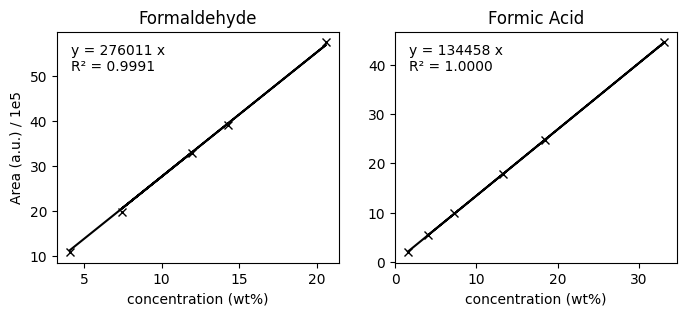

In [100]:
for dictionary in dictionaries:                                                                                      
    m, residuals, _, _ = np.linalg.lstsq(dictionary['concentrations'].reshape(-1,1), dictionary['areas'])
    slope = m[0]
    dictionary['slope'] = slope                                                                                          
    r2 = r_squared(lambda x: slope*x, dictionary['concentrations'], dictionary['areas'])
    dictionary['r2'] = r2

# plot
fig, (ax1, ax2) = plt.subplots(figsize = (8, 3), ncols = 2)                                 
for dictionary, ax in zip(np.array([FALD, FA]), [ax1, ax2]):                                           
    ax.plot(dictionary['concentrations'], dictionary['areas']/1e5, 'kx')            
    ax.plot(dictionary['concentrations'], dictionary['concentrations']*dictionary['slope']/1e5, 'k-')     
    ax.set_title(dictionary['name'])                                                                
    ax.set_xlabel('concentration (wt%)')                                                            
    eq_text = f"y = {dictionary['slope']:.0f} x\nR² = {dictionary['r2']:.4f}"
    ax.text(0.05, 0.95, eq_text, transform=ax.transAxes, va='top')
ax1.set_ylabel('Area (a.u.) / 1e5')                                                                 
plt.show()

**Define Function for Chromatogram Extraction**

In [101]:
def extract_chromatogram(filepath):                                         # define function to extract chromatogram data from file
    with open(filepath, 'r', encoding='latin1') as f:                       # open file with correct encoding
        lines = f.readlines()                                               # read all lines into a list

    for i, line in enumerate(lines):
        if line.strip().startswith('[LC Chromatogram(Detector B-Ch1)]'):    # search for the start of the chromatogram data
            data_start = i + 8                                              # skip 8 lines to get to the actual data
            break                                                           # break loop, found start

    data_lines = [] 
    for line in lines[data_start:]:                                         # start reading lines from the data start index
        if not line.strip() or line.strip().startswith('['):                # stop if we reach an empty line or the start of a new section (indicated by '[')
            break
        data_lines.append(line)                                             # otherwise, append line to data lines

    data = np.genfromtxt(data_lines, usecols=(0,1))                         # extract data
    data_export = np.column_stack([60*data[:,0], data[:,1]])                # convert time to seconds and stack with intensity 
    return data_export                                                      # return the data for chromatogram

**Show Example Chromatograms and fit them appropriately**

Tailing is observed for the *Formaldehyde* peaks at approximately 640 s. To account for that, a exponentially modified gaussian fit can be used and has previously been applied by [Kong *et al*.](https://www.sciencedirect.com/science/article/pii/S0021967305011465)

The *Formic Acid* peaks at approximately 660 s exhibit fronting. To account for this, a mirrored version of the exponentially modified gaussian is used for fitting

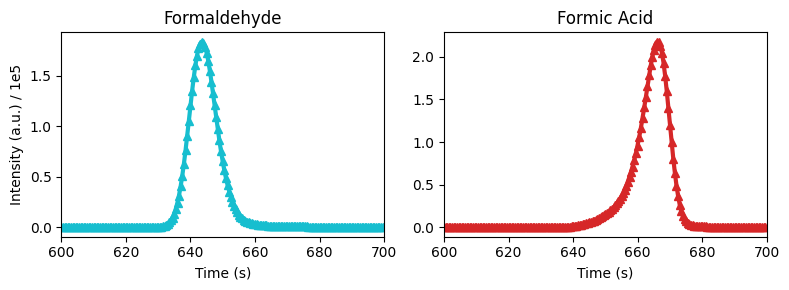

In [102]:
files = ['CAL-FALD-2.txt', 'CAL-FA-3.txt']

# load samples for each calibration (FALD, FA)
idx_1, idx_2 = 1200, 1400  # indices for zoomed-in plot
samples, fits = [], []
for f in files:
    sample = extract_chromatogram(path + f)
    idx_max = np.argmax(sample[:,1])
    i1, i2 = max(0, idx_max - 70), min(len(sample), idx_max + 70)
    x = sample[i1:i2,0]
    y = sample[i1:i2,1]
    if f in FALD['files']:
        popt, _ = curve_fit(EMG, x, y, p0=FALD['p0'])
        fit = EMG(x, *popt)
    else:
        popt, _ = curve_fit(EMG_mirrored, x, y, p0=FA['p0'])
        fit = EMG_mirrored(x, *popt)
    samples.append(sample)
    fits.append(np.array([x, fit]).T)

# plot zoomed-in chromatograms
fig, axes = plt.subplots(ncols=2, figsize=(8,3))

for ax, samp, fit, d in zip(axes, samples, fits, dictionaries):
    ax.plot(samp[idx_1:idx_2,0], samp[idx_1:idx_2,1] / 1e5, f'{d["color"]}^')
    ax.plot(fit[:,0], fit[:,1] / 1e5, f'{d["color"]}-', lw=3)
    ax.set_xlim(samp[idx_1,0], samp[idx_2,0])
    ax.set_title(d['name'])

axes[0].set_ylabel('Intensity (a.u.) / 1e5')
for ax in axes:
    ax.set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

**Determination of a linear relationship between the peak area *h* and $\sigma$ or $\tau$, respectively** 

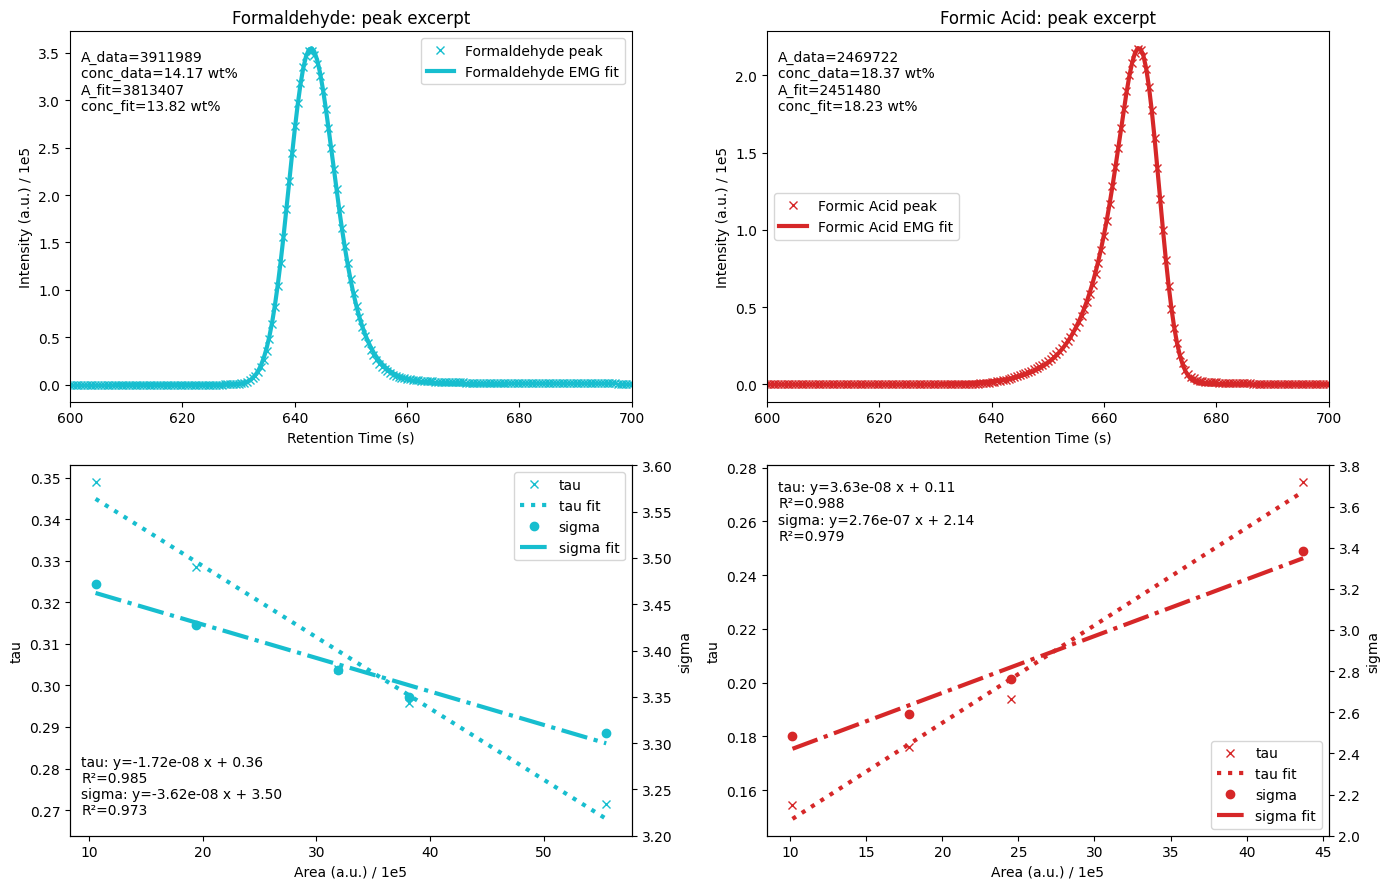

In [103]:
def analyze_calibration(dictionary):
    """Fit the main peak of each trace and collect calibration metrics."""
    model = EMG if dictionary['name'] == 'Formaldehyde' else EMG_mirrored # choose model based on species for tailing and fronting
    for file in dictionary['files']:
        sample = extract_chromatogram(path + file)
        idx_max = np.argmax(sample[:,1])
        i1, i2 = max(0, idx_max - 70), min(len(sample), idx_max + 70)
        x = sample[i1:i2,0]
        y = sample[i1:i2,1]
        popt, _ = curve_fit(model, x, y, p0=dictionary['p0'])
        h, mu, sigma, tau = popt
        dictionary['hs'].append(h)
        dictionary['mus'].append(mu)
        dictionary['sigmas'].append(sigma)
        dictionary['taus'].append(tau)
        dictionary['fits'].append(np.column_stack((x, model(x, *popt))))
    dictionary['hs'] = np.array(dictionary['hs'])
    dictionary['mus'] = np.array(dictionary['mus'])
    dictionary['sigmas'] = np.array(dictionary['sigmas'])
    dictionary['taus'] = np.array(dictionary['taus'])

analyze_calibration(FALD)
analyze_calibration(FA)

def fit_info(x, y):
    """Return a simple linear calibration fit and its R²."""
    coeffs = np.polyfit(x, y, 1)
    return coeffs

#Exclude first two points of FA calibration for fitting
FALD_fit_sigma = np.polyfit(FALD['hs'], FALD['sigmas'], 1)
FALD_fit_tau = np.polyfit(FALD['hs'], FALD['taus'], 1)
FALD_r2_sigma = r_squared(np.poly1d(FALD_fit_sigma), FALD['hs'], FALD['sigmas'])
FALD_r2_tau = r_squared(np.poly1d(FALD_fit_tau), FALD['hs'], FALD['taus'])

# Exclude first two FA calibration points as they did not fit well to the EMG model, likely due to low concentrations
FA_fit_mask = np.argsort(FA['hs'])[2:]
FA_fit_sigma = np.polyfit(FA['hs'][FA_fit_mask], FA['sigmas'][FA_fit_mask], 1)
FA_fit_tau = np.polyfit(FA['hs'][FA_fit_mask], FA['taus'][FA_fit_mask], 1)
FA_r2_sigma = r_squared(np.poly1d(FA_fit_sigma), FA['hs'][FA_fit_mask], FA['sigmas'][FA_fit_mask])
FA_r2_tau = r_squared(np.poly1d(FA_fit_tau), FA['hs'][FA_fit_mask], FA['taus'][FA_fit_mask])

def plot_peak(ax, file):
    """Plot a peak excerpt and overlay the local EMG fit."""
    d = FALD if file in FALD['files'] else FA
    sample = extract_chromatogram(path + file)
    ax.plot(sample[:,0], sample[:,1]/1e5, f'{d['color']}x', label=f'{d['name']} peak')
    ax.plot(d['fits'][d['files'].index(file)][:,0], d['fits'][d['files'].index(file)][:,1]/1e5, f'{d["color"]}-', lw=3, label=f'{d['name']} EMG fit')
    A_data = d['areas'][d['files'].index(file)]
    A_fit = d['hs'][d['files'].index(file)]
    conc_data = A_data / d['slope']
    conc_fit = A_fit / d['slope']
    ax.text(0.02, 0.95, f'A_data={A_data:.0f}\nconc_data={conc_data:.2f} wt%\nA_fit={A_fit:.0f}\nconc_fit={conc_fit:.2f} wt%', transform=ax.transAxes, va='top')
    ax.set_title(f'{d['name']}: peak excerpt')
    ax.set_xlabel('Retention Time (s)')
    ax.set_ylabel('Intensity (a.u.) / 1e5')
    ax.set_xlim(600, 700)
    ax.legend()

def plot_calibration(ax, dictionary, fit_tau, fit_sigma, r2_tau, r2_sigma):
    """Plot tau and sigma trends versus concentration."""
    d = dictionary
    if d == FA:
        mask = np.argsort(d['hs'])[2:]
        hs = d['hs'][mask]
        sigma_arr = d['sigmas'][mask]
        tau_arr = d['taus'][mask]
    else:
        hs, sigma_arr, tau_arr = d['hs'], d['sigmas'], d['taus']

    ax2 = ax.twinx()
    ax.plot(hs / 1e5, tau_arr, f'{d["color"]}x', label='tau')
    ax2.plot(hs / 1e5, sigma_arr, f'{d["color"]}o', label='sigma')
    
    if d == FALD:
        ax2.set_ylim(3.2, 3.6)
    else:
        ax2.set_ylim(2.0, 3.8)

    # Linien für die Trends generieren
    xs = np.linspace(np.min(hs), np.max(hs), 100)
    
    # KORREKTUR 1: Koeffizienten an poly1d übergeben
    ax.plot(xs / 1e5, np.poly1d(fit_tau)(xs), f'{d["color"]}:', lw=3, label='tau fit')
    ax2.plot(xs / 1e5, np.poly1d(fit_sigma)(xs), f'{d["color"]}-.', lw=3, label='sigma fit')

    # KORREKTUR 2: Eindeutige und sauber getrennte Variablen für die Textbox
    tau_text = f'tau: y={fit_tau[0]:.2e} x + {fit_tau[1]:.2f}\nR²={r2_tau:.3f}'
    sigma_text = f'sigma: y={fit_sigma[0]:.2e} x + {fit_sigma[1]:.2f}\nR²={r2_sigma:.3f}'
    
    if d == FALD:
        ax.text(0.02, 0.05, tau_text + '\n' + sigma_text, transform=ax.transAxes, va='bottom')
    else:
        ax.text(0.02, 0.96, tau_text + '\n' + sigma_text, transform=ax.transAxes, va='top')
        
    ax.set_xlabel('Area (a.u.) / 1e5')
    ax.set_ylabel('tau')
    ax2.set_ylabel('sigma')
    
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, loc='best')

# KORREKTUR 3: Der Aufruf liefert nun alle benötigten Variablen (inklusive R²) an die Funktion
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
plot_peak(axes[0,0], FALD['files'][2])
plot_peak(axes[0,1], FA['files'][2])

# Hier übergeben wir jetzt die Koeffizienten UND die berechneten R²-Werte
plot_calibration(axes[1,0], FALD, FALD_fit_tau, FALD_fit_sigma, FALD_r2_tau, FALD_r2_sigma)
plot_calibration(axes[1,1], FA, FA_fit_tau, FA_fit_sigma, FA_r2_tau, FA_r2_sigma)

fig.tight_layout()
plt.show()

**Validation of the method with mixtures of Formic acid and Formaldehyde in known composition**

All concentrations in wt.%, all masses in g

In [104]:
FALD_conc, FA_conc = 5.64, 9.53                                                     
names = np.array(['FAFALD-1', 'FAFALD-2', 'FAFALD-3', 'FAFALD-4'])                      
FALD_mass = np.array([0.4588, 0.9178, 0.4492,0.2454])                           
FA_mass = np.array([0.6864, 0.3066, 0.5593,0.3887]) 
Water_mass = np.array([0, 0, 0.4244,0.6128])                             
wt_perc_FALD = FALD_conc*FALD_mass/(FALD_mass+FA_mass+Water_mass)                          
wt_perc_FA = FA_conc*FA_mass/(FALD_mass+FA_mass+Water_mass)

col_width = 20
header = f"{'Name':^{col_width}} {'wt% Formaldehyde':^{col_width}} {'wt% Formic Acid':^{col_width}}"
print(header)
print('-' * len(header))
for name, wtFALD, wtFA in zip(names, wt_perc_FALD, wt_perc_FA):
    print(f"{name:^{col_width}} {wtFALD:^{col_width}.2f} {wtFA:^{col_width}.2f}")

        Name           wt% Formaldehyde     wt% Formic Acid   
--------------------------------------------------------------
      FAFALD-1               2.26                 5.71        
      FAFALD-2               4.23                 2.39        
      FAFALD-3               1.77                 3.72        
      FAFALD-4               1.11                 2.97        


**Examine the accuracy of the unconstrained fit**

In [105]:
def run_validation(sample_specs, constraint_name, model_func, indices, extract_result):
    """
    Fit and plot validation samples using a given constraint model.
    
    Parameters
    ----------
    extract_result : callable(popt, x) -> (h_fald, mu_fald, sigma_fald, tau_fald, h_fa, mu_fa, sigma_fa, tau_fa, fald_curve, fa_curve)
    """
    print(constraint_name)
    fig, axes = plt.subplots(ncols=4, figsize=(18, 4.5), sharey=True)

    for ax, (sample_file, wt_fald_real, wt_fa_real) in zip(axes, sample_specs):
        print(sample_file.center(80, '='))
        print(f"{'Peak':^10} {'h':^10} {'μ':^8} {'σ':^8} {'τ':^8} {'Peak pos.':^10} {'wt% real':^10} {'wt% fit':^10}")
        print('- ' * 40)

        sample = extract_chromatogram(path + sample_file)
        i1 = max(0, np.argmax(sample[:,1]) - 70)
        i2 = min(len(sample), np.argmax(sample[:,1]) + 70)
        x, y = sample[i1:i2, 0], sample[i1:i2, 1]

        p0 = list(FALD['p0'][indices]) + list(FA['p0'][indices])
        lb = list(FALD['lower_bounds'][indices]) + list(FA['lower_bounds'][indices])
        ub = list(FALD['upper_bounds'][indices]) + list(FA['upper_bounds'][indices])

        popt, _ = curve_fit(model_func, x, y, p0=p0, bounds=[lb, ub])
        h1, mu1, sigma1, tau1, h2, mu2, sigma2, tau2, fald_c, fa_c = extract_result(popt, x)

        print(f"{'FALD':^10} {h1:^10.0f} {mu1:^8.1f} {sigma1:^8.3f} {tau1:^8.3f} "
              f"{x[np.argmax(fald_c)]:^10.1f} {wt_fald_real:^10.2f} {h1/FALD['slope']:^10.2f}")
        print(f"{'FA':^10} {h2:^10.0f} {mu2:^8.1f} {sigma2:^8.3f} {tau2:^8.3f} "
              f"{x[np.argmax(fa_c)]:^10.1f} {wt_fa_real:^10.2f} {h2/FA['slope']:^10.2f}")
        print()

        ax.plot(sample[:,0], sample[:,1] / 1e5, 'C0o')
        ax.plot(x, fald_c / 1e5, f'{FALD["color"]}:', lw=3)
        ax.plot(x, fa_c / 1e5, f'{FA["color"]}--', lw=3)
        ax.plot(x, (fald_c + fa_c) / 1e5, 'k-', lw=3)
        ax.set_xlim(600, 700)
        ax.set_title(sample_file.replace('.txt', ''))
        ax.set_xlabel('Retention Time (s)')
        ax.legend(['Data', 'FALD fit', 'FA fit', 'Sum fit'])

    axes[0].set_ylabel('Intensity (a.u.) / 1e5')
    fig.tight_layout()
    plt.show()

In [106]:
sample_specs = [
    ('TEST-FAFALD-1.txt', wt_perc_FALD[0], wt_perc_FA[0]),
    ('TEST-FAFALD-2.txt', wt_perc_FALD[1], wt_perc_FA[1]),
    ('TEST-FAFALD-3.txt', wt_perc_FALD[2], wt_perc_FA[2]),
    ('TEST-FAFALD-4.txt', wt_perc_FALD[3], wt_perc_FA[3]),
]

Unconstrained fit
===============================TEST-FAFALD-1.txt================================
   Peak        h         μ        σ        τ     Peak pos.   wt% real   wt% fit  
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
   FALD      652318    641.0    3.361    0.261     643.5       2.26       2.36   
    FA       758031    664.2    2.428    0.166     661.5       5.71       5.64   

===============================TEST-FAFALD-2.txt================================
   Peak        h         μ        σ        τ     Peak pos.   wt% real   wt% fit  
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
   FALD     1278887    640.9    3.395    0.243     643.5       4.23       4.63   
    FA       209865    659.8    2.401    0.300     658.0       2.39       1.56   

===============================TEST-FAFALD-3.txt================================
   Peak        h         μ        σ        τ     Peak pos.   wt% real   wt% fit  
-

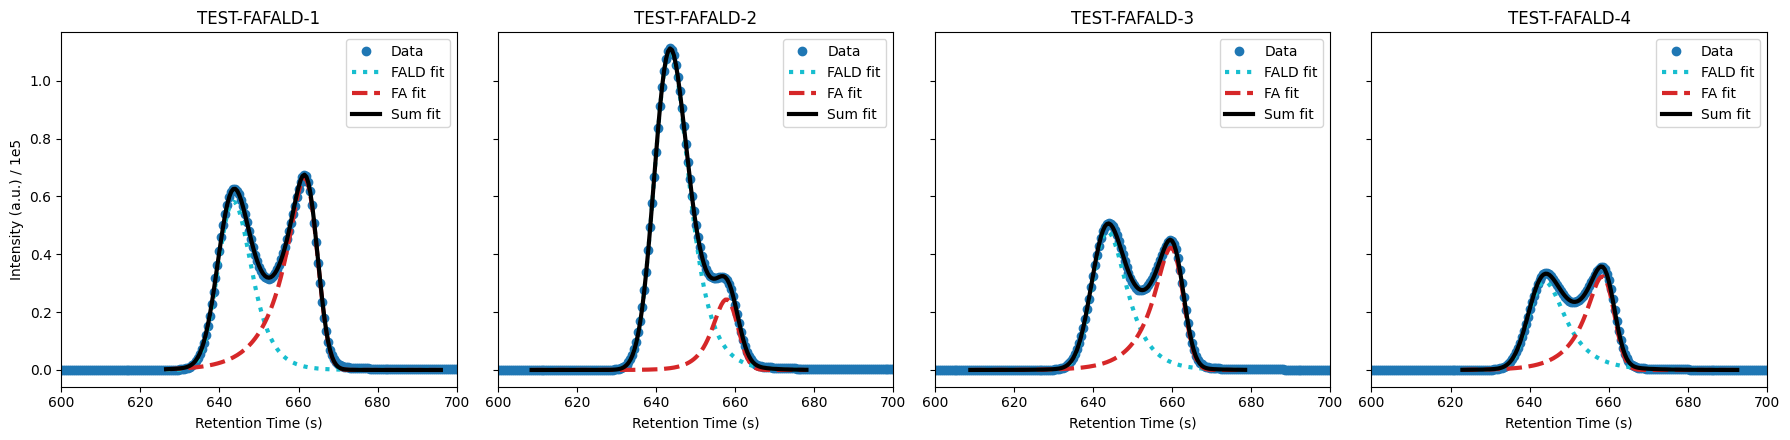

In [107]:
# --- Unconstrained fit ---
def extract_unconstrained(popt, x):
    h1, mu1, sigma1, tau1 = popt[:4]
    h2, mu2, sigma2, tau2 = popt[4:]
    return (h1, mu1, sigma1, tau1, h2, mu2, sigma2, tau2,
            EMG(x, h1, mu1, sigma1, tau1),
            EMG_mirrored(x, h2, mu2, sigma2, tau2))

run_validation(sample_specs, 'Unconstrained fit', EMGsTailFront,
               [0,1,2,3], extract_unconstrained)

Sigma-constrained fit
===============================TEST-FAFALD-1.txt================================
   Peak        h         μ        σ        τ     Peak pos.   wt% real   wt% fit  
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
   FALD      620676    641.3    3.478    0.311     643.5       2.26       2.25   
    FA       792244    664.3    2.361    0.153     661.5       5.71       5.89   

===============================TEST-FAFALD-2.txt================================
   Peak        h         μ        σ        τ     Peak pos.   wt% real   wt% fit  
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
   FALD     1238655    641.0    3.456    0.267     643.5       4.23       4.49   
    FA       248741    660.1    2.211    0.215     658.0       2.39       1.85   

===============================TEST-FAFALD-3.txt================================
   Peak        h         μ        σ        τ     Peak pos.   wt% real   wt% fit

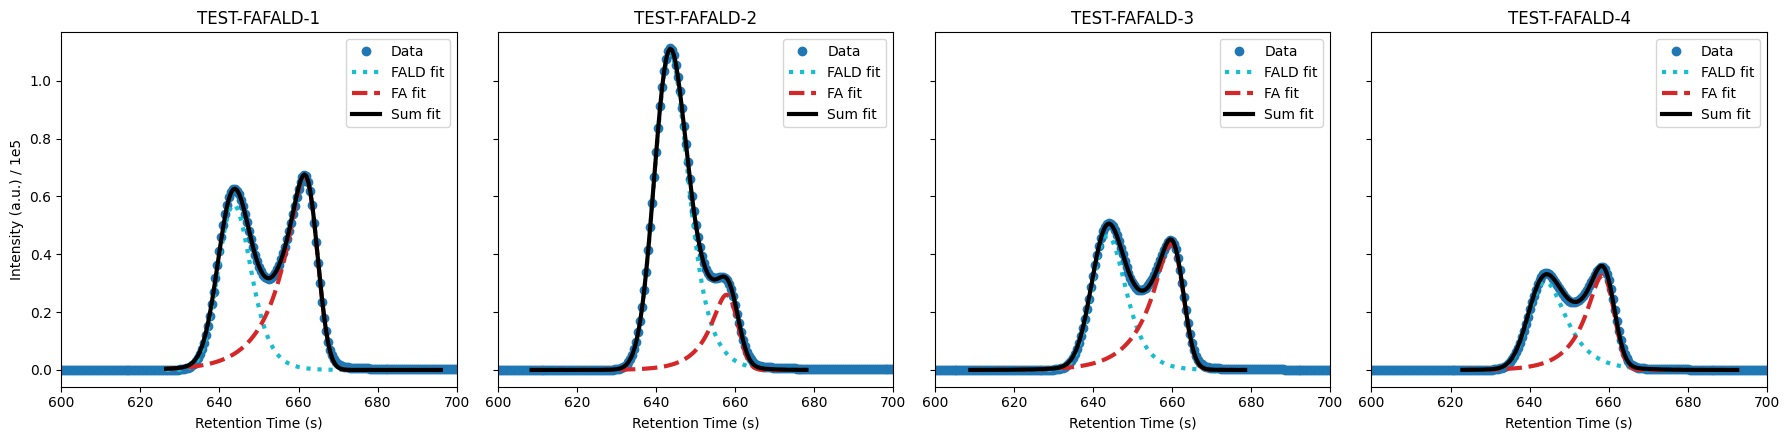

In [108]:
# --- Sigma-constrained fit ---
sig_EMGsTailFront = make_sigma_constrained_EMGsTailFront(FALD_fit_sigma, FA_fit_sigma)

def extract_sigma(popt, x):
    h1, mu1, tau1 = popt[:3]
    h2, mu2, tau2 = popt[3:]
    
    sigma1 = FALD_fit_sigma[1] + h1 * FALD_fit_sigma[0]
    sigma2 = FA_fit_sigma[1] + h2 * FA_fit_sigma[0]
    
    return (h1, mu1, sigma1, tau1, 
            h2, mu2, sigma2, tau2,
            EMG(x, h1, mu1, sigma1, tau1),
            EMG_mirrored(x, h2, mu2, sigma2, tau2))

run_validation(sample_specs, 'Sigma-constrained fit', sig_EMGsTailFront, [0,1,3], extract_sigma)

Tau-constrained fit
===============================TEST-FAFALD-1.txt================================
   Peak        h         μ        σ        τ     Peak pos.   wt% real   wt% fit  
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
   FALD      592060    641.5    3.470    0.353     643.5       2.26       2.15   
    FA       823972    664.4    2.359    0.142     661.5       5.71       6.13   

===============================TEST-FAFALD-2.txt================================
   Peak        h         μ        σ        τ     Peak pos.   wt% real   wt% fit  
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
   FALD     1118335    641.4    3.477    0.344     643.5       4.23       4.05   
    FA       380463    660.4    2.386    0.126     657.5       2.39       2.83   

===============================TEST-FAFALD-3.txt================================
   Peak        h         μ        σ        τ     Peak pos.   wt% real   wt% fit  

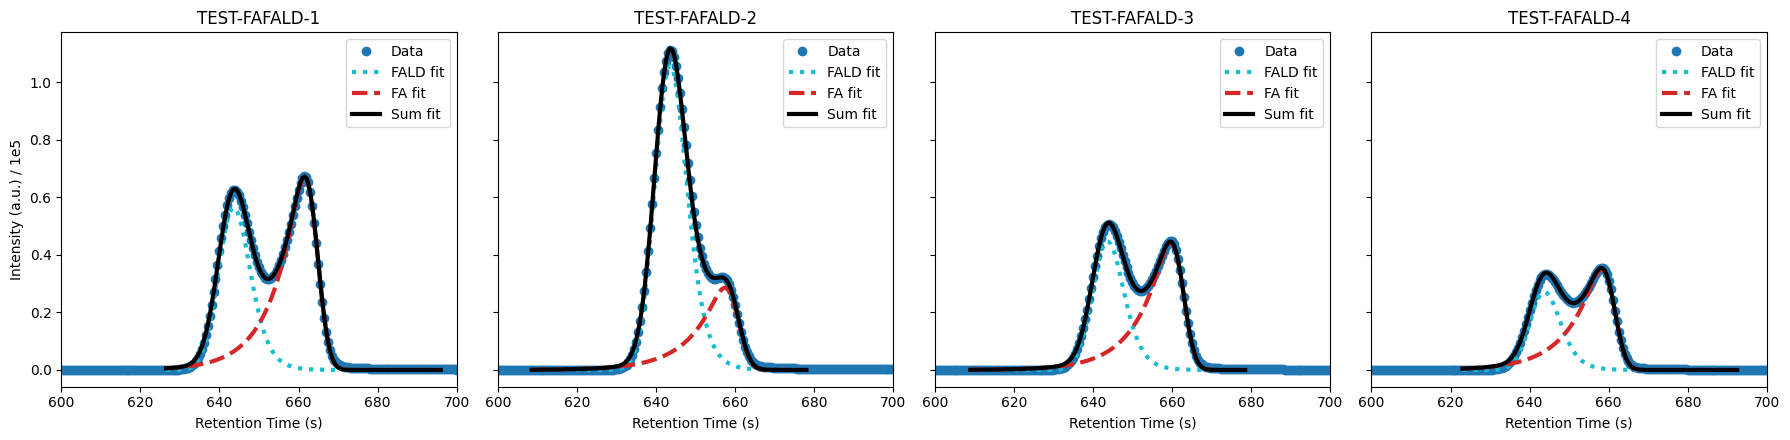

In [109]:
# --- Tau-constrained fit ---
FALD_tau_c, FA_tau_c = FALD_fit_tau, FA_fit_tau

def tau_c_EMGsTF(x, h1, mu1, sigma1, h2, mu2, sigma2):
    def tau_emg(x, h, mu, sigma, coeffs):
        return EMG(x, h, mu, sigma, coeffs[1] + h * coeffs[0])
    def tau_emg_mirrored(x, h, mu, sigma, coeffs):
        return EMG_mirrored(x, h, mu, sigma, coeffs[1] + h * coeffs[0])
    return (tau_emg(x, h1, mu1, sigma1, FALD_tau_c) +
            tau_emg_mirrored(x, h2, mu2, sigma2, FA_tau_c))

def extract_tau(popt, x):
    h1, mu1, s1 = popt[:3]
    h2, mu2, s2 = popt[3:]
    t1 = FALD_tau_c[1] + h1 * FALD_tau_c[0]
    t2 = FA_tau_c[1] + h2 * FA_tau_c[0]
    return (h1, mu1, s1, t1, h2, mu2, s2, t2,
            EMG(x, h1, mu1, s1, t1),
            EMG_mirrored(x, h2, mu2, s2, t2))

run_validation(sample_specs, 'Tau-constrained fit', tau_c_EMGsTF,
               [0,1,2], extract_tau)

Fully constrained fit
===============================TEST-FAFALD-1.txt================================
   Peak        h         μ        σ        τ     Peak pos.   wt% real   wt% fit  
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
   FALD      592506    641.5    3.479    0.353     643.5       2.26       2.15   
    FA       824393    664.4    2.370    0.142     661.5       5.71       6.13   

===============================TEST-FAFALD-2.txt================================
   Peak        h         μ        σ        τ     Peak pos.   wt% real   wt% fit  
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
   FALD     1117600    641.4    3.460    0.344     643.5       4.23       4.05   
    FA       377803    660.4    2.246    0.126     657.5       2.39       2.81   

===============================TEST-FAFALD-3.txt================================
   Peak        h         μ        σ        τ     Peak pos.   wt% real   wt% fit

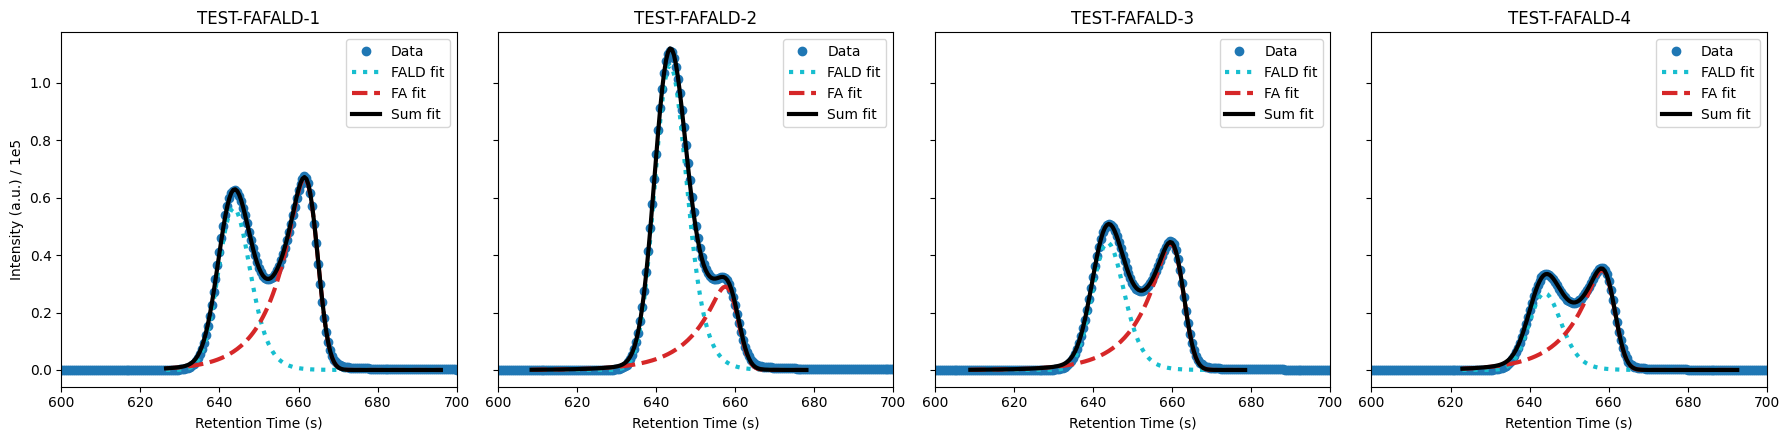

In [110]:
# --- Fully constrained fit ---
full_emg = make_constrained_EMG(FALD_fit_tau, FALD_fit_sigma)
full_emg_m = make_constrained_EMG_mirrored(FA_fit_tau, FA_fit_sigma)
full_c_EMGsTF = make_constrained_EMGsTailFront(
    FALD_fit_tau, FALD_fit_sigma,
    FA_fit_tau, FA_fit_sigma,
)

def extract_full(popt, x):
    h1, mu1 = popt[:2]
    h2, mu2 = popt[2:]
    s1 = FALD_fit_sigma[1] + h1 * FALD_fit_sigma[0]
    t1 = FALD_fit_tau[1] + h1 * FALD_fit_tau[0]
    s2 = FA_fit_sigma[1] + h2 * FA_fit_sigma[0]
    t2 = FA_fit_tau[1] + h2 * FA_fit_tau[0]
    return (h1, mu1, s1, t1, h2, mu2, s2, t2,
            full_emg(x, h1, mu1),
            full_emg_m(x, h2, mu2))

run_validation(sample_specs, 'Fully constrained fit', full_c_EMGsTF,
               [0,1], extract_full)